**Oasis Infobyte - OIBSIP - Data Science**

**Author : Gauri Pardhi**

**TASK 3 : Email Spam Detection**

**Objective**

**ML models are trained on labeled datasets to classify emails as spam or non-spam. Features like word frequencies and sender information are used for classification and the model is regularly updated to adapt to evolving spamming techniques.**

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


**Import libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load the dataset**

In [3]:
df = pd.read_csv("emails.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


**Display the first record**

In [4]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


**Check dataset information**

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (5728, 2)

Column Names:
Index(['text', 'spam'], dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.6 MB


**Check missing value**

In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
text    0
spam    0
dtype: int64


**Remove missing value**

In [7]:
df = df.dropna()

print("Dataset shape after removing missing values:")
print(df.shape)

Dataset shape after removing missing values:
(5728, 2)


**Check Spam and Non-Spam distribution**

In [8]:
print(df.columns.tolist())

['text', 'spam']


In [9]:
print(df["spam"].value_counts())

spam
0    4360
1    1368
Name: count, dtype: int64


**Visualize spam emails** 

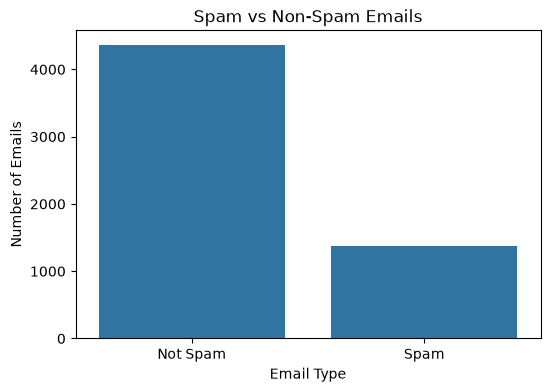

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(x="spam", data=df)

plt.title("Spam vs Non-Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

plt.xticks([0, 1], ["Not Spam", "Spam"])

plt.show()

**Separate input and output**

In [11]:
X = df["text"]
y = df["spam"]

print("Input data:")
print(X.head())

print("\nTarget data:")
print(y.head())

Input data:
0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: text, dtype: str

Target data:
0    1
1    1
2    1
3    1
4    1
Name: spam, dtype: int64


**Split the dataset**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4582,)
Testing data: (1146,)


**Convert email text into numbers using TF-IDF**

In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4582, 5000)
Testing TF-IDF shape: (1146, 5000)


**Create the Machine Learning model**
**We'll use Multinomial Naive Bayes**

In [ ]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


**Make prediction**

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0]


**Calculate accuracy**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9808027923211169
Accuracy Percentage: 98.08027923211169 %


**Classification report**

In [ ]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Spam", "Spam"]
    )
)

Classification Report:

              precision    recall  f1-score   support

    Not Spam       0.98      0.99      0.99       872
        Spam       0.97      0.95      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146



**Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[865   7]
 [ 15 259]]


**Plot the confusionn matrix**

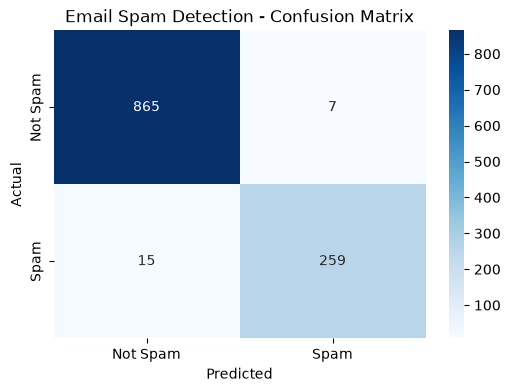

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Spam", "Spam"],
    yticklabels=["Not Spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Email Spam Detection - Confusion Matrix")

plt.show()

**Actual VS Predicted Graph**

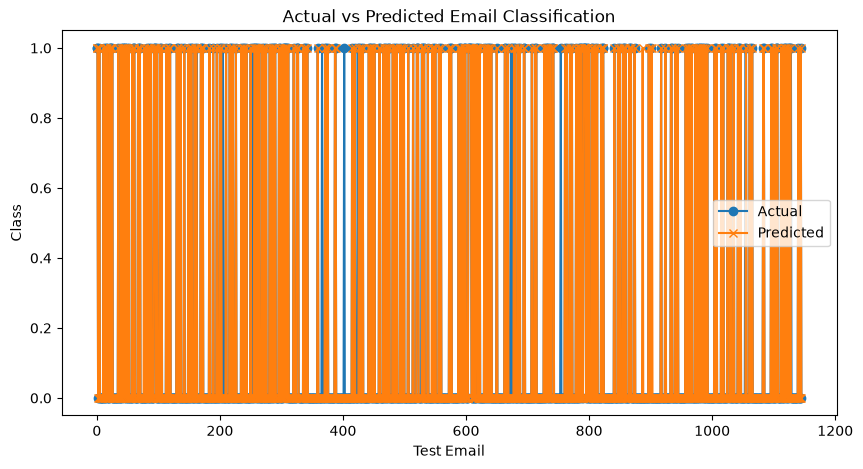

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker="x",
    label="Predicted"
)

plt.xlabel("Test Email")
plt.ylabel("Class")
plt.title("Actual vs Predicted Email Classification")

plt.legend()

plt.show()

**Predict a new email**

In [ ]:
new_email = [
    "Congratulations! You have won a $1000 cash prize. Click here to claim your reward."
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

if prediction[0] == 1:
    print("🚨 Prediction: SPAM")
else:
    print("✅ Prediction: NOT SPAM")

🚨 Prediction: SPAM


**Text a normal email**

In [ ]:
new_email = [
    "Hello, please attend the college meeting tomorrow at 10 AM."
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

if prediction[0] == 1:
    print("🚨 Prediction: SPAM")
else:
    print("✅ Prediction: NOT SPAM")

✅ Prediction: NOT SPAM


**Text a multiple emails**

In [ ]:
emails = [
    "Congratulations! You won a free iPhone. Claim your prize now!",
    "Please submit your assignment by tomorrow.",
    "URGENT! You have won 10 lakh rupees. Call now!",
    "Hey, are you coming to college tomorrow?",
    "You have been selected for a cash reward. Click the link now!"
]

emails_tfidf = vectorizer.transform(emails)

predictions = model.predict(emails_tfidf)

for email, prediction in zip(emails, predictions):
    
    if prediction == 1:
        result = "SPAM"
    else:
        result = "NOT SPAM"
    
    print(result, "→", email)

NOT SPAM → Congratulations! You won a free iPhone. Claim your prize now!
NOT SPAM → Please submit your assignment by tomorrow.
NOT SPAM → URGENT! You have won 10 lakh rupees. Call now!
NOT SPAM → Hey, are you coming to college tomorrow?
SPAM → You have been selected for a cash reward. Click the link now!


**Display result in a table**

In [ ]:
results = pd.DataFrame({
    "Email": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Email,Actual,Predicted
0,"Subject: good day friend dear friend , my na...",1,1
1,Subject: wallstreet pulse good day to all bro...,1,1
2,Subject: sap time sheets on the o : \ research...,0,0
3,Subject: holiday gift thank you so much for y...,0,0
4,Subject: unbelievable new homes made easy im ...,1,1
5,"Subject: resume , cv . , etc . dear mr . kami...",0,0
6,Subject: re : summer internship position ravi...,0,0
7,Subject: re : meeting sorry for the reschedul...,0,0
8,"Subject: re : blood bank vince , i must apol...",0,0
9,Subject: re : greeting from charles happy new...,0,0


**Save the Trained model**

In [ ]:
import joblib

joblib.dump(model, "spam_email_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


**Final Project report**

In [ ]:
print("====================================")
print("   EMAIL SPAM DETECTION PROJECT")
print("====================================")
print("Machine Learning Algorithm: Naive Bayes")
print("Text Vectorization: TF-IDF")
print("Accuracy:", accuracy * 100, "%")
print("====================================")

   EMAIL SPAM DETECTION PROJECT
Machine Learning Algorithm: Naive Bayes
Text Vectorization: TF-IDF
Accuracy: 98.08027923211169 %
